Shape: (7857, 8)

Columns: ['model_name', 'model_year', 'kms_driven', 'owner', 'location', 'mileage', 'power', 'price']

Misssing Value:
 model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage       11
power         31
price          0
dtype: int64

Data Type:
 model_name    object
model_year     int64
kms_driven    object
owner         object
location      object
mileage       object
power         object
price          int64
dtype: object

Sample Data:
                          model_name  model_year      kms_driven        owner  \
0     Bajaj Avenger Cruise 220 2017        2017        17000 Km  first owner   
1  Royal Enfield Classic 350cc 2016        2016        50000 Km  first owner   
2               Hyosung GT250R 2012        2012        14795 Km  first owner   
3        Bajaj Dominar 400 ABS 2017        2017  Mileage 28 Kms  first owner   
4             Jawa Perak 330cc 2020        2020         2000 Km  first owner   

      location       m

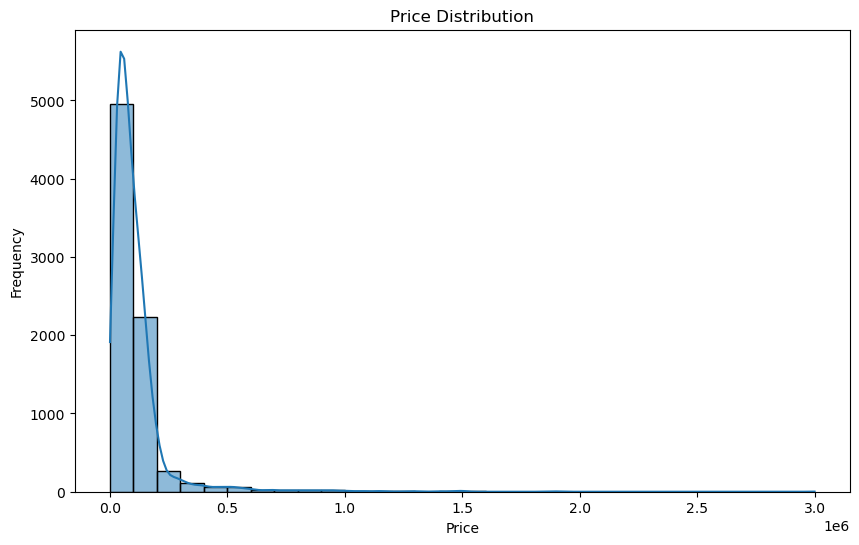

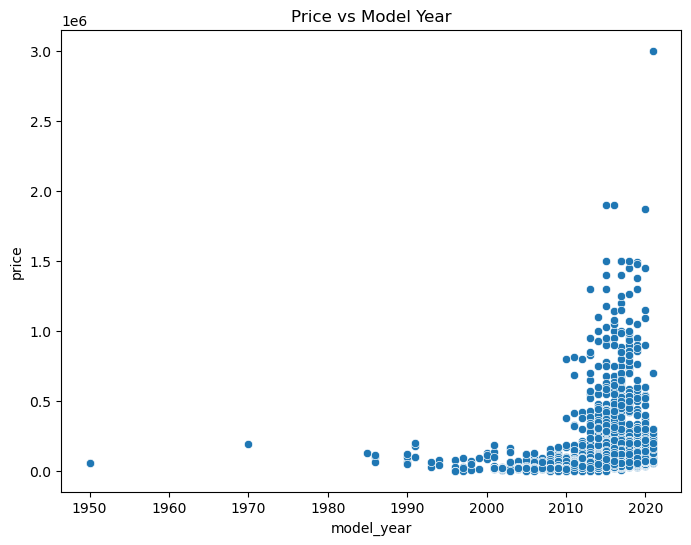

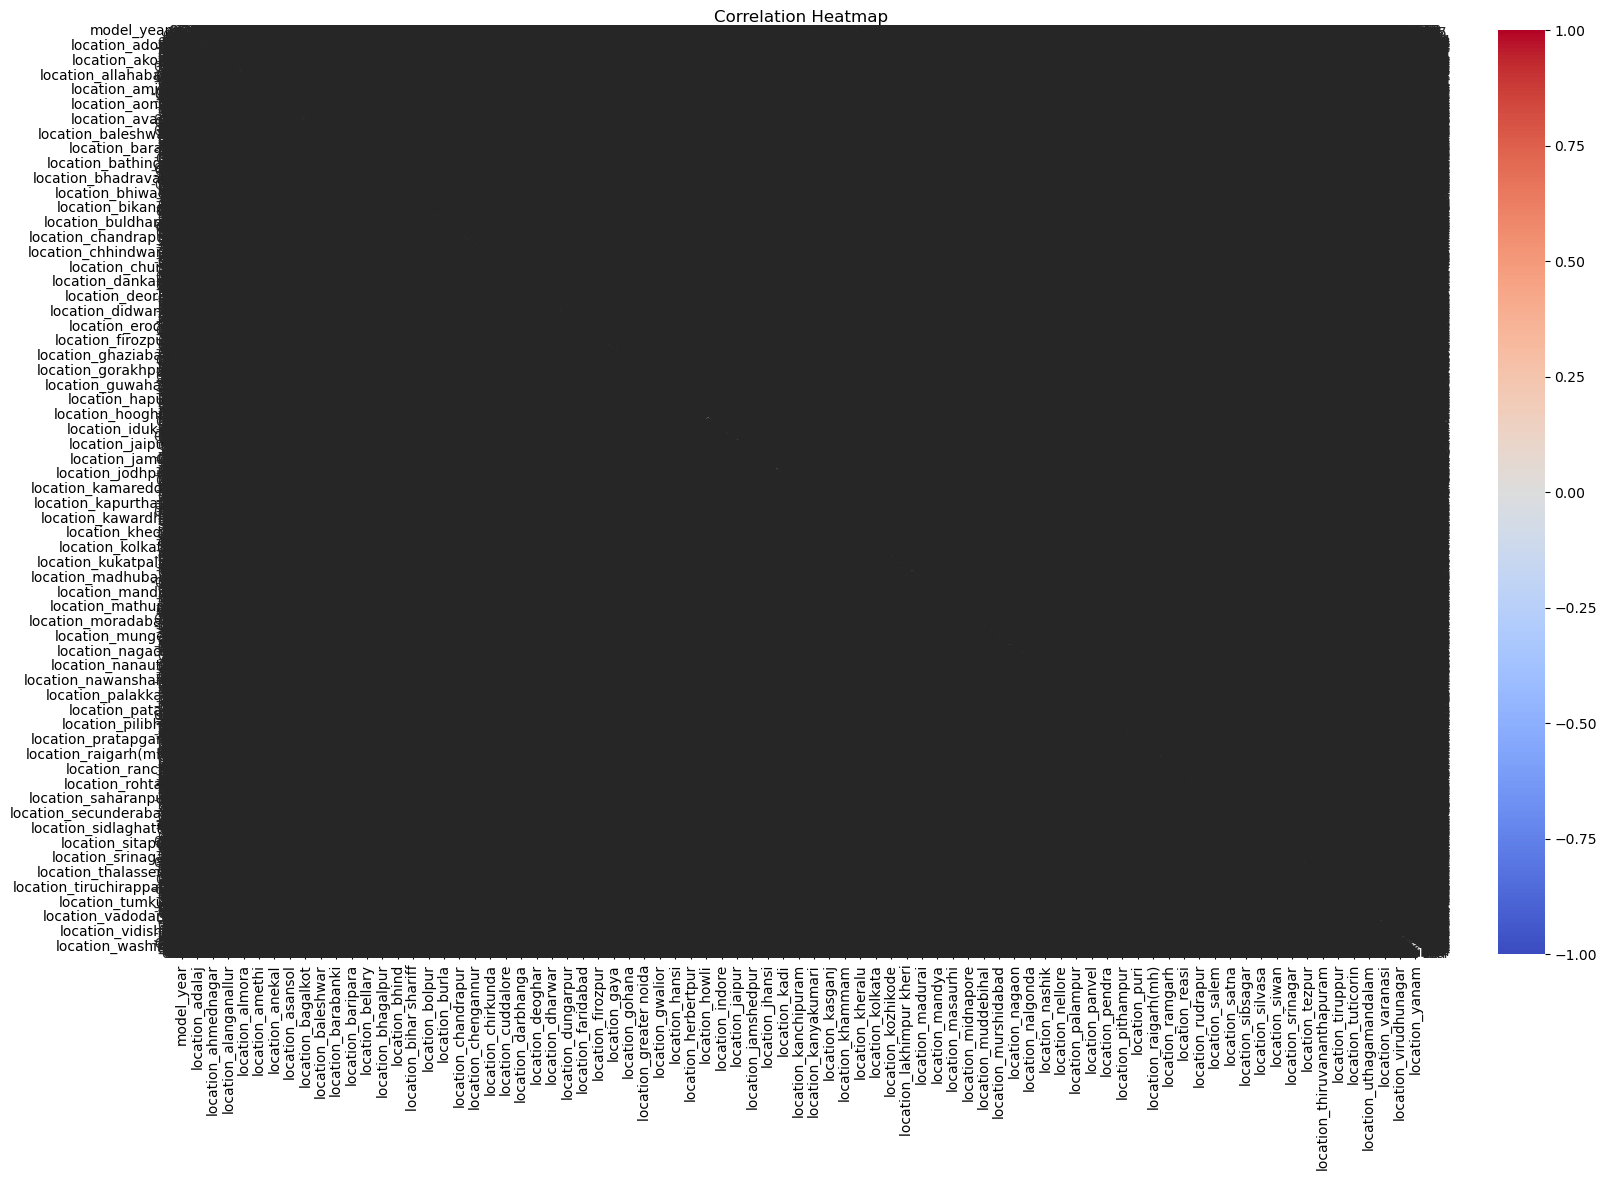

ValueError: could not convert string to float: 'TVS Star City Plus 110cc 2018'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Load data
df = pd.read_csv('C:/Users/HP/Documents/DA_projects/Bike/bikes.csv')
df.columns = df.columns.str.strip() # Clean columns names
print("Shape:",df.shape)
print("\nColumns:",df.columns.tolist())
print("\nMisssing Value:\n",df.isnull().sum())
print("\nData Type:\n", df.dtypes)
print("\nSample Data:\n", df.head())
# data rows with missing values
df.dropna(inplace=True)
# remove duplicates 
df.drop_duplicates(inplace=True)
# Convert prices to numeric if needed
df['price']= pd.to_numeric(df['price'], errors='coerce')
# Age of Bike
Current_year = 2025
df['bike_age']=Current_year - df['model_year']
#  One-hot categorical features
categorical_cols=['brand','owner','location']
available_cols = [col for col in categorical_cols if col in df.columns]
df= pd.get_dummies(df,columns=available_cols, drop_first=True)
# Price distribution 
plt.figure(figsize=(10,6)) 
sns.histplot(df['price'],kde=True, bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Price Vs Model Year
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='model_year', y='price')
plt.title('Price vs Model Year')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
# Define Feature and target
x= df.drop('price', axis=1)
y = df['price']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model training
model = LinearRegression()
model.fit(x_train_scaled, y_train)

